# 04 - Evaluation and Visualization

This notebook combines classical + ML metric summaries, visualizes comparisons, and selects best model per target.

In [4]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACTS_DIR = BASE_DIR / 'artifacts'

classical = pd.read_csv(ARTIFACTS_DIR / 'classical_metrics_summary.csv')
ml = pd.read_csv(ARTIFACTS_DIR / 'ml_metrics_summary.csv')

all_summary = pd.concat([classical, ml], ignore_index=True)
all_summary = all_summary.sort_values(['target', 'RMSE']).reset_index(drop=True)
all_summary.head()

,target,model,MAE,MSE,RMSE,MAPE
0,daily_orders,ARIMA,9.797719,152.641481,12.290706,7.245702
1,daily_orders,SARIMA,9.862489,152.757520,12.293453,7.307824
2,daily_orders,Holt,9.764759,153.552253,12.330644,7.270014
3,daily_orders,ETS,9.998952,157.625119,12.484049,7.447087
4,daily_orders,LinearRegression,10.127928,163.495018,12.651407,7.654634


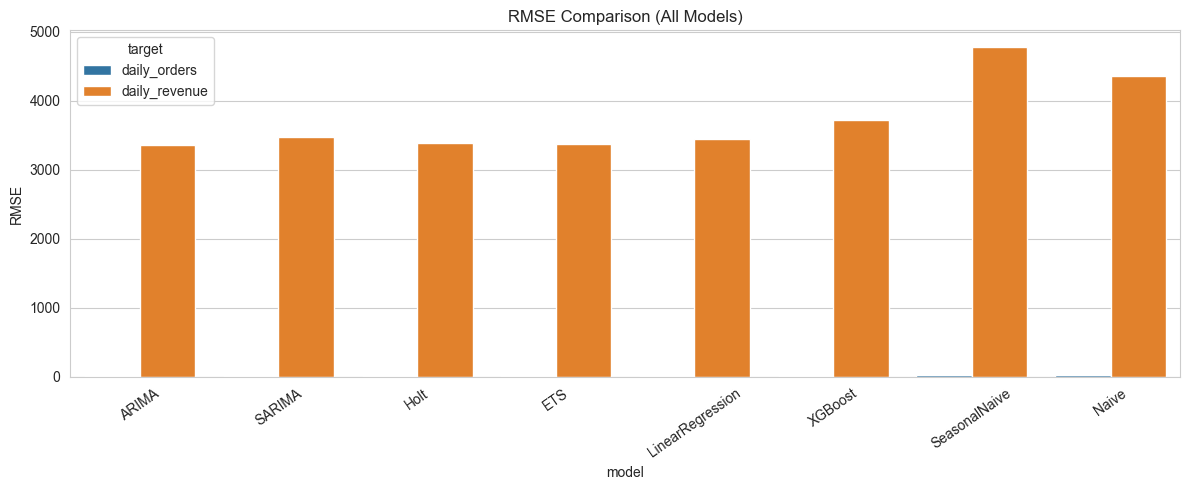

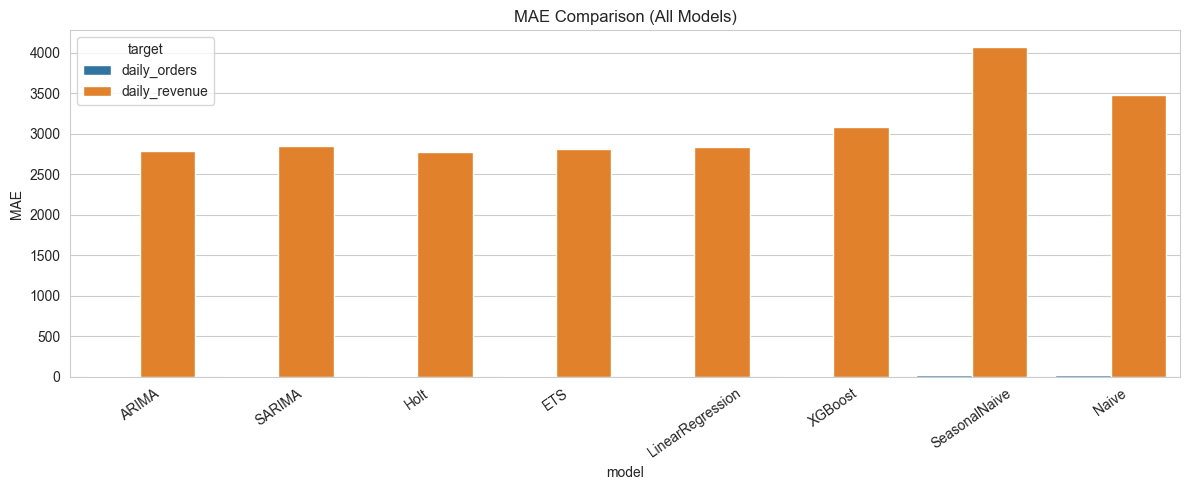

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=all_summary, x='model', y='RMSE', hue='target', ax=ax)
ax.set_title('RMSE Comparison (All Models)')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '04_rmse_comparison_all_models.png', dpi=140)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=all_summary, x='model', y='MAE', hue='target', ax=ax)
ax.set_title('MAE Comparison (All Models)')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / '04_mae_comparison_all_models.png', dpi=140)
plt.show()

In [6]:
best_rows = all_summary.groupby('target', as_index=False).first()
best_rows = best_rows[['target', 'model', 'MAE', 'MSE', 'RMSE', 'MAPE']]

best_map = {row['target']: row['model'] for _, row in best_rows.iterrows()}

all_summary.to_csv(ARTIFACTS_DIR / 'all_metrics_summary.csv', index=False)
best_rows.to_csv(ARTIFACTS_DIR / 'best_models_table.csv', index=False)

with open(ARTIFACTS_DIR / 'best_models_selected.json', 'w', encoding='utf-8') as f:
    json.dump(best_map, f, indent=2)

best_rows

,target,model,MAE,MSE,RMSE,MAPE
0,daily_orders,ARIMA,9.797719,1.526415e+02,12.290706,7.245702
1,daily_revenue,ARIMA,2794.837431,1.142162e+07,3364.485249,8.194805
